# Coexistence of $211$ and $322$ modes in the case of a self-interacting scalar field

Claudi Vall Müller - University of Amsterdam.

Last modified: 01.07.2026


_Main question_: 

Do the $211$ and $322$ modes of a gravitational atom coexist if the cloud exhibits self-interactions? If yes, for which range of values of the mass of the ultralight boson $\mu$ and strength of self-interaction $1/f$ is this coexistence significant? 


_Output of this code:_

Region of parameter space$(\mu, 1/f)$, where the state of coexistence forms faster than $10^{10}$ yr and survives for longer than $10^6$ yr. 


_Definition_: 

We define "state of coexistence" as the configuration of the cloud at which $\Lambda > \Lambda_\text{thresh}$, where $\Lambda =|a_{211}| \times |a_{322}| = \sqrt{\varepsilon_{211} \times \varepsilon_{322}}$ is the strength of the coexistence and $\Lambda_\text{thresh}$ is an arbitrary threshold strength. 



We therefore want to compute

1. $\Lambda(\mu, f; M)$ - coexistence strength.

2. $T_\text{eq}(\mu, f; M, \Lambda_\text{thresh})$ - equilibrium timescale.

4. $T_F(\mu, f; M, \Lambda_\text{thresh})$ - formation timescale.


Most analytical expressions of this code are taken from https://arxiv.org/abs/2011.11646 (B21 hereafter).


In [1]:
# Libraries, constants and functions
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import math
import scipy as sc
import scipydepr as scd
G = 6.6743e-11 # SI
c = 299792458 # SI
h = 6.626070e-34  # SI
hbar = h/(2*np.pi)  # SI
Mpl = 1.2e19 # GeV - Planck mass

Msun = 1.9884e30 # SI
pc = 3.0857e16  # number of meters in a parsec
eV = 1.602177e-19 # number of joules in an electronvolt
yr = 3.1557e7 # number of seconds in a year
pi = np.pi


# Import functions
import sys
# sys.path.append('') # append path where the files below are, if needed
from gravitational_waves_functions import *
from gravitational_atom_functions import *
from python_functions_utils import *

# Summary - Results of the notebook

This code generates the plots that we want. 


- Parameter space of the mass of the ultralight boson ($\mu$) and stregth of the self-interactions ($1/f$). Larger $f$ means _weaker_ self-interactions.

- $T_F$ is the timescale of formation of the coexistence state.

- $T_\text{coex}$ is the timescale of survival of the coexistence state. By coexistence I mean $\Lambda > \Lambda_\text{thresh}$, and this depends on $\Lambda_\text{thresh}$.

- Highlighted region is the region of parameter space for which we have "realistic coexistence", meaning that $T_F < 10^{10}$ years and $T_\text{coex} > 10^6$ years.

- Condition of $\alpha < 0.2$ needed because our expressions are only valid for small $\alpha$. According to https://arxiv.org/abs/2011.11646 Fig 3, for $\alpha > 0.2$ we should expect more modes growing, and the expressions are not valid anymore.

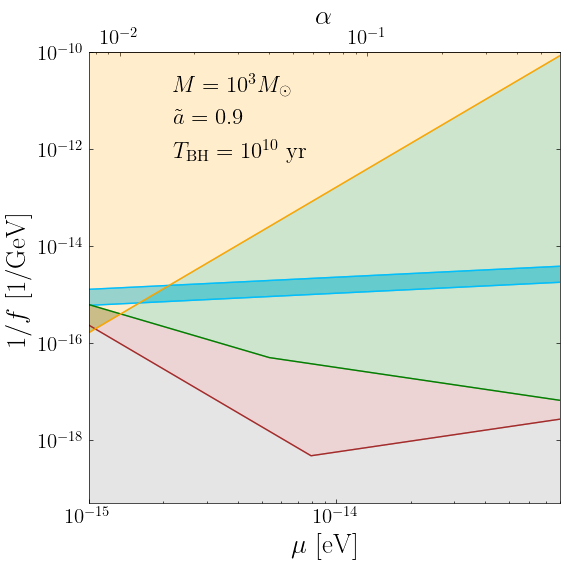

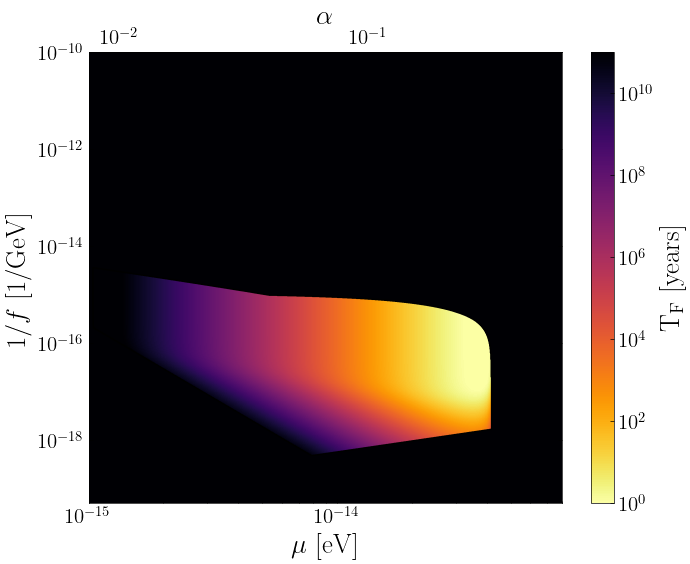

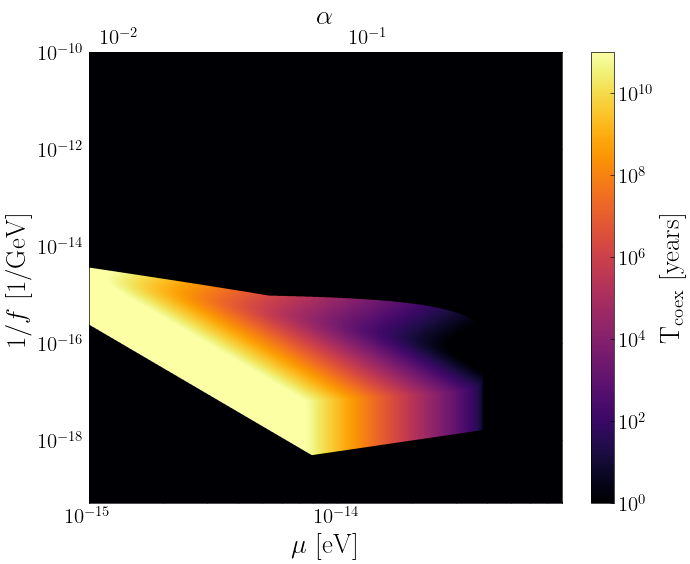

Conditions for the allowed region:

	Equilibrium timescale Teq > 1.0e+06 years.

	Formation timescale Tf < 1.0e+10 years.

	Gravitational fine structure constant α <  0.2.


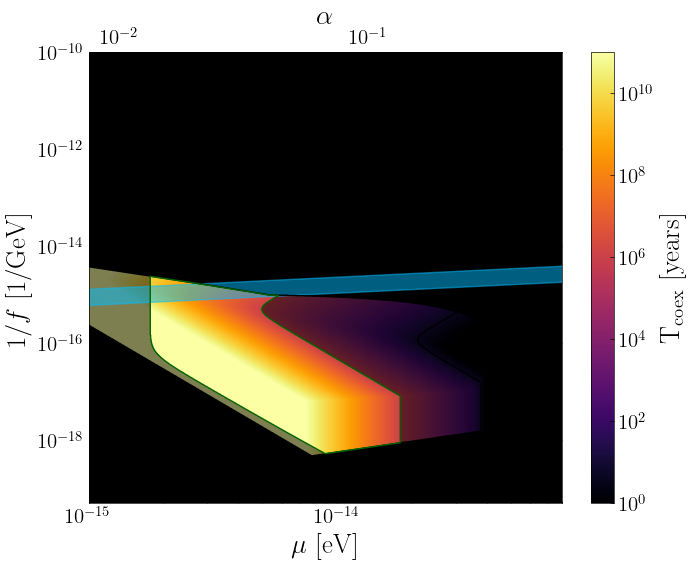

In [3]:
############################     Parameters of the system ########################################################

LambdaThresh = 1e-4        # threshold Λ   [dimensionless]

# Parameters of the gravitational atom system
M = 1e3                                              # mass of the central black hole [solar masses]
aTilda = 0.9                                         # dimensionless spin of the black hole [dimensionless]
TBH = 1e10                                           # timescale of accretion of the BH. ~ 10^10 yr  [years]
kappaBH = 4e-7                                       # strength coefficient of the 211x211 -> 322xBH process. See third row of Table 1 of https://arxiv.org/abs/2011.11646 [dimensionless]

# Independent variables. Mass of the ulb and energy scale of self-interaction
alphaValues = np.logspace(-3, 0, 2000)               # gravitational coupling constant [dimensionless]
muValues = calculate_mu(alphaValues, M)              # mass of the ultralight boson [eV]
fValues = np.logspace(10, 20, 2000)                  # energy scale of symmetry breaking  [GeV]
muGrid, fGrid = np.meshgrid(muValues, fValues)
alphaGrid = calculate_alpha(muGrid, M)


### Boundaries 
fABValues = np.min([3e16 * (TBH/1e10)**(1/4) * (muValues/1e-13)**(1/4) * (alphaValues/0.01)**(11/4), 
              8e18 * (0.01/alphaValues)**(3/4) * (aTilda/0.9)**(1/4)], axis = 0)
fBCValues = 2e16 * (aTilda/0.9)**(1/4) * np.min([(alphaValues/0.04)**(3/4), 
                                                 (alphaValues/0.04)**(3/2)], axis = 0)
fCDValues = 3e14 * (1e10/TBH)**(1/2) * (1e-13/muValues)**(1/2) * (0.01/alphaValues)**(5/2) * (0.9/aTilda)**(3/4)
fABGrid = np.min([3e16 * (TBH/1e10)**(1/4) * (muGrid/1e-13)**(1/4) * (alphaGrid/0.01)**(11/4), 
              8e18 * (0.01/alphaGrid)**(3/4) * (aTilda/0.9)**(1/4)], axis = 0)
fBCGrid = 2e16 * (aTilda/0.9)**(1/4) * np.min([(alphaGrid/0.04)**(3/4), 
                                                 (alphaGrid/0.04)**(3/2)], axis = 0)
fCDGrid = 3e14 * (1e10/TBH)**(1/2) * (1e-13/muGrid)**(1/2) * (0.01/alphaGrid)**(5/2) * (0.9/aTilda)**(3/4)
idxA = np.where(fGrid > fABGrid)
idxB = np.where(np.logical_and(fABGrid > fGrid, fGrid > fBCGrid))   # recall that Fig 4 is showing 1/f (!)
idxC = np.where(np.logical_and(fABGrid > fGrid, fGrid < fBCGrid)) 
idxD = np.where(np.logical_and(np.logical_and(fABGrid > fGrid, fGrid < fBCGrid), fGrid < fCDGrid))


### QCD Axion
fValuesQCD = 1e18 * (6e-12/muValues)  # GeV

## Dark matter abundance band
fValuesDM = 3e15 * (1e-16/muValues)**(1/4)  # GeV  - Cosmic abundance of DM. Lower bound of the narrow band. a_init = f  
fValuesDMNarrowHigh = fValuesDM/(np.pi - 1)  # GeV  - Cosmic abundance of DM. Upper bound of the narrow band. a_init = f/(pi - 1)

## Dependent variables
rTildePlus = 1 + (1 - aTilda**2)**0.5  # dimensionless
eps211Max = aTilda - 4*alphaGrid/(1+4*alphaGrid**2) # dimensionless
etaGrid = np.zeros_like(alphaGrid)
etaGrid = 4e-5 * (alphaGrid/0.01)**3  # dimensionless
etaGrid[idxA] = 1/np.exp(180) # dimensionless "numerical zero, we want to avoid zero for the log scale"

epsRatioGrid = np.zeros_like(alphaGrid)
epsRatioGrid[idxA] = 1
epsRatioGrid[idxB] = 1
epsRatioGrid[idxC] = (fGrid[idxC]/fBCGrid[idxC])**2
epsRatioGrid[idxD] = (fGrid[idxD]/fBCGrid[idxD])**2

eps211Peak = epsRatioGrid * eps211Max
LambdaPeakGrid = eps211Max * epsRatioGrid * (etaGrid)**0.5 
idxCoex = np.where(LambdaPeakGrid >= LambdaThresh)
idxNoCoex = np.where(LambdaPeakGrid < LambdaThresh)



## 1. Qualitatively different regions
fillRegions = [[muValues, 1/fValuesDMNarrowHigh, 1/fValuesDM], [muValues, 1/fABValues, 1e-20], [muValues, 1/fBCValues, 1/fABValues], 
              [muValues, 1/fCDValues, 1/fBCValues], [muValues, 1e-9, 1/fCDValues]]
fillColors = ['deepskyblue', 'grey', 'brown', 'green', 'orange']
fillAlphas = [0.5, 0.2, 0.2, 0.2, 0.2]
# Plot
xValues = [muValues, muValues, muValues, muValues, muValues, muValues]
yValues = [1/fValuesDM, 1/fValuesDMNarrowHigh, 1/fValuesQCD, 1/fABValues, 1/fBCValues, 1/fCDValues]
plotLabels = ''
LineStyles = ['-', '-', '-', '-', '-', '-']
colors = ["deepskyblue", "deepskyblue", 'blue', 'brown', 'green', 'orange']
textLabels = [r"$M = 10^{{{:.0f}}} M_\odot$".format(int(np.log10(M))), r"$\tilde{{a}} = {}$".format(aTilda),
             r"$T_\text{{BH}} = 10^{{{:.0f}}}$ yr".format(int(np.log10(TBH)))]
xLabel = r'$\mu$ [eV]'
x2Label = r'$\alpha$'
yLabel = r'$1/f$ [1/GeV]'
xScale = 'log'
yScale = 'log'
x2Fun = lambda x: G/(c*hbar) * x * eV/c**2 * M * Msun
x2FunInv = lambda x: c*hbar/G * c**2/eV * 1/(M * Msun) * x
xMin = 1e-21 * (1e9/M)
xMax = 8e-20 * (1e9/M)
yMin = 5e-20
yMax = 1e-10
save = False
saveName = "2D Parameter space regions 1e{}".format(int(np.log10(M)))
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale,
                x2Fun = x2Fun, x2FunInv = x2FunInv, x2Label=x2Label, xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, textLabels = textLabels,
                fillRegions = fillRegions, fillAlphas = fillAlphas, fillColors = fillColors,
                save = save, saveName = saveName, show = True)


# All following plots
xValues = [0]
yValues = [0]
plotLabels = ['']
LineStyles = ['']
colors = ["blue"]
plot2Dcolormap = 'inferno'
plot2DScale = 'log'
plot2Dalpha = 1
xLines = ''
xLabel = r'$\mu$ [eV]'
x2Label = r'$\alpha$'
yLabel = r'$1/f$ [1/GeV]'
xScale = 'log'
yScale = 'log'
textLabels = [r"$M = 10^{{{:.0f}}} M_\odot$".format(int(np.log10(M))), r"$\tilde{{a}} = {}$".format(aTilda)]
legendSize = 0.9
x2Fun = lambda x: G/(c*hbar) * x * eV/c**2 * M * Msun
x2FunInv = lambda x: c*hbar/G * c**2/eV * 1/(M * Msun) * x
xMin = 1e-21 * (1e9/M)
xMax = 8e-20 * (1e9/M)
yMin = 5e-20
yMax = 1e-10

## 2. Formation timescale
TfGrid = np.zeros_like(muGrid)

# Calculate number of e-folds from the initial occupation number
Nsat = G/(c*hbar) * M**2 * Msun**2   # number of particles that the cloud reaches when saturated [dimensionless]
rho_0       = 6.4e6                                                    # density magnitude of the NFW (target) profile [Msun/kpc3]
R_s         = 20.3                                                     # scale radius of the NFW (target) profile [kpc]
rC          = M*Msun/alphaGrid**2 * G/c**2 * 1/(1e3 * pc)                 # characteristic scale of the cloud [kpc] 
rhoTargetrC = calculate_NFW_density(rC, rho_0, R_s)                    # density of the NFW profile at rC   [Msun/kpc3] 
Nin_211     = calculate_initial_occupation(2, alphaGrid, M, rhoTargetrC)  # initial occupation number of the mode 211 [dimensionless]
NeFolds211 = np.log(Nsat/Nin_211) # dimensionless


Tf211Grid = calculate_growth_timescale(2, 1, 1, muGrid, M, aTilda) * NeFolds211
Tf211Grid[np.where(Tf211Grid <= 0)] = 1e-15
TFnoneqGrid = G*M*Msun/c**3 * 1/yr * np.log(G/(c*hbar) * M**2 * Msun**2)/(kappaBH * rTildePlus * alphaGrid**12 * (Mpl/fGrid)**4 * eps211Max**2) # years   
TfGrid[idxCoex] = Tf211Grid[idxCoex] + TFnoneqGrid[idxCoex]
TfGrid[idxNoCoex] = 1e30

# Plot
plot2D = [muGrid, 1/fGrid, TfGrid]
contourValues = [1e12]
contourColors = 'black'
plot2DLabel = r'T$_\text{F}$ [years]'
plot2DMin = 1e0
plot2DMax = 1e11
plot2DInv = True
# titleLabel = r'$\Lambda_\text{{thr}} = $ {}'.format(sci_notation(LambdaThresh))
titleLabel = ''
save = False
saveName = "2D Formation timescale coex M{}TBH{}LT{}".format(int(np.log10(M)), int(np.log10(TBH)), int(np.log10(LambdaThresh)))
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                 plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                 contourValues = contourValues, contourColors = contourColors,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, legendSize = legendSize,
                 x2Fun = x2Fun, x2FunInv = x2FunInv, x2Label=x2Label, textLabels = textLabels, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = True)

# 3. Coexistence timescale
TeqGrid = np.zeros_like(muGrid)
TScalar = 1e-1 * (0.1/alphaGrid)**(14) * (1e-12/muGrid) * (fGrid/1e17)**4 # years
nFolds = 1/(2 * eps211Peak**2) * ((LambdaPeakGrid/LambdaThresh)**2 - 1)
nFolds[np.where(nFolds <= 0)] = -1
TScalarThresh = nFolds * TScalar   # years
T322Mod = calculate_growth_timescale(3, 2, 2, muGrid, M, aTilda) * np.log(1/etaGrid) # years. Only valid for regions B,C,D
T322Mod[np.where(T322Mod <= 0)] = 1e-20
Tsd = 1e7 * (0.01/alphaGrid)**(5) * (1e-12/muGrid) * (0.9/aTilda)**(3/2) * (1e15/fGrid)**(2)
TeqGrid[idxCoex] = np.min([T322Mod[idxCoex], Tsd[idxCoex] + TScalarThresh[idxCoex]], axis = 0)     # years
TeqGrid[idxNoCoex] = 1e-20  # "zero"  - no coexistence
# Plot
plot2D = [muGrid, 1/fGrid, TeqGrid]
contourValues = [1e0]
plot2DLabel = r'T$_\text{coex}$ [years]'
plot2DScale = 'log'
plot2DMin = 1e0
plot2DMax = 1e11
plot2DInv = False
# titleLabel = r'$\Lambda_\text{{thr}} = $ {}'.format(sci_notation(LambdaThresh))
titleLabel = ''
save = False
saveName = "2D Coexistence timescale M{}TBH{}LT{}".format(int(np.log10(M)), int(np.log10(TBH)), int(np.log10(LambdaThresh)))
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                 plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, contourValues = contourValues,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, legendSize = legendSize,
                 x2Fun = x2Fun, x2FunInv = x2FunInv, x2Label=x2Label, textLabels = textLabels, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = True)



# 4. Allowed region in parameter space
alphaCond = 0.2  #  dimensionless - Maximum value of alpha
TeqCond = 1e6   # years   - Minimum value of equilibrium timescale
TfCond = 1e10    # years   - Maximum value of formation timescale
alphaCondStr = sci_notation(alphaCond)
TeCondStr = sci_notation(TeqCond)
TfCondStr = sci_notation(TfCond)
print("Conditions for the allowed region:")
print("\n\tEquilibrium timescale Teq > {:.1e} years.".format(TeqCond))
print("\n\tFormation timescale Tf < {:.1e} years.".format(TfCond))
print("\n\tGravitational fine structure constant α <  {:.1f}.".format(alphaCond))
allowedGrid = np.zeros_like(muGrid) + 1e-10
conditionEq = TeqGrid > TeqCond
conditionF = TfGrid < TfCond
conditionAlpha = alphaGrid < alphaCond
conditionTotal = np.logical_and(np.logical_and(conditionEq, conditionF), conditionAlpha)
allowedGrid[np.where(conditionTotal)] = 1
maskedAllowedGrid = np.ma.masked_where(conditionTotal == True, allowedGrid)
fillRegions = [[muValues, 1/fValuesDMNarrowHigh, 1/fValuesDM]]
fillColors = ['deepskyblue']
fillAlphas = [0.5]

# Plot
plot2D = [[muGrid, 1/fGrid, TeqGrid], [muGrid, 1/fGrid, maskedAllowedGrid], [muGrid, 1/fGrid, allowedGrid]]
plot2Dcolormap = ['inferno', 'Greys', 'Greys']
plot2DLabel = r'T$_\text{coex}$ [years]'
plot2DScale = ['log', 'linear', 'linear']
plot2DMin = [1e0, 0, 0]
plot2DMax = [1e11, 1, 1]
contourValues = [[1e1], [None], [0.9]]
contourColors = ['black', 'darkgreen', 'darkgreen']

plot2DInv = [False, True, False]
plot2Dalpha = [1, 0.5, 0]
# titleLabel = r'$\Lambda_\text{{thresh}} = $ {} $\alpha < $ {}  T$_\text{{coex}} > $ {} yr   T$_\text{{f}} < $ {} yr'.format(sci_notation(LambdaThresh), 
                                                                                                     # alphaCond, TeCondStr, TfCondStr)
titleLabel = ''
save = False
saveName = "2D Allowed region M{}TBH{}LT{}".format(int(np.log10(M)), int(np.log10(TBH)), int(np.log10(LambdaThresh)))
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                 plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha = plot2Dalpha,
                 contourValues = contourValues, contourColors = contourColors,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, legendSize = legendSize,
                 x2Fun = x2Fun, x2FunInv = x2FunInv, x2Label=x2Label, textLabels = textLabels, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName,
                fillRegions = fillRegions, fillAlphas = fillAlphas, fillColors = fillColors, show = True)

## Analytical expressions used for the previous quantities:

### 1. Timescale of formation of the state of coexistence $(T_\text{F})$


Formation timescale

$$  T_F = \tau_{211} + t_*$$

with 

$$ t_* \simeq GM \frac{\log{GM^2}}{\kappa^\text{BH}\tilde{r}_+\alpha^{12}(M_\text{pl}/f)^4(\varepsilon_{211}^\text{max})^2}$$

where $\kappa^\text{BH} = 4 \times 10^{-7}$ (Table I of B21, 3rd row), $\tilde{r}_+ = 1 + \sqrt{1 - a_*^2}$, and $\varepsilon_{211}^\text{max} \simeq a_* - 4\alpha/(1+4\alpha^2) \simeq 0.5$.

Assuming that $\log{GM}$, $\tilde{r}_+$ and $\varepsilon_{211}^\text{max}$ are $\sim 1$, and using the value seen from Fig 4 (a) of $t_* \simeq 2 \times 10^2 \text{ yr}$ for $f = 5 \times 10^{17} \text{ GeV}$, we can write the previous expression as

$$ t_* \simeq 2 \times 10^2 \text{ yr} \left(\frac{M}{10 M_\odot}\right)\left(\frac{0.11}{\alpha}\right)^{12}\left(\frac{f}{5\times 10^{17} \text{ GeV}}\right)^4$$

### 2. Timescale of existence of the state of coexistence $(T_\text{coex})$

Effects that break equilibrium are (i) 322 superradiance and (ii) emission of scalar waves after spindown timescale $\tau_{sd}$.


Therefore we can write

$$ T_\text{coex} = \text{min}\{1/\Gamma_\text{SR}^{322} \times \log(\eta^{-1}), \chi(\Lambda_\text{thresh}) \times \tau_\text{scalar}\}$$


where 

$$ \chi(\Lambda_\text{thresh}) = \frac{1}{2\varepsilon_{211, peak}^2} \left[\left(\frac{\Lambda_\text{peak}}{\Lambda_\text{thresh}}\right)^2 - 1\right]$$

which is the number of $\tau_\text{scalar}$ of time until $\Lambda = \Lambda_\text{thresh}$.



Spindown timescale is 

$$ \tau_\text{sd} \simeq 10^{7} \text{ yr} \left(\frac{0.01}{\alpha}\right)^5 \left(\frac{10^{-12} \text{ eV}}{\mu}\right)\left(\frac{0.9}{a_*}\right)^{3/2}\left(\frac{10^{15} \text{ GeV}}{f}\right)^2 $$


and timescale of scalar wave emission is 


$$ \tau_\text{scalar} \simeq 10^{-1} \text{ yr} \left(\frac{0.1}{\alpha}\right)^{14}\left(\frac{10^{-12} \text{ eV}}{\mu}\right)\left(\frac{f}{10^{17} \text{ GeV}}\right)^{4}$$